# County-Level Mapping & Spatial Cluster Analysis
## Dermatology Access and Melanoma Mortality

**Environment:** Google Colab (Python)

This notebook produces **true county-level choropleth maps** from the `fips` column in
your dataset, then runs a **population-weighted spatial cluster analysis**.

### What it makes

| # | Output | Type |
|---|---|---|
| 1–3 | `dermatologists`, `dermatology_rate`, `anyderm` | Univariate county choropleths |
| 4–6 | Each of the above × `melanoma_mortality_rate` | **Bivariate** choropleths (3×3 colour grid) |
| 7 | Global Moran's I | 4 specifications, incl. population weighting |
| 8–10 | LISA cluster maps | Local Moran's I, EB rate-smoothed |
| 11 | **Bivariate LISA** | Derm access vs. neighbouring mortality |
| 12 | Priority county table | Low access + high mortality, ranked |

### How the population weight (`pop`) is used

Population weighting is not a single knob — this notebook applies it in three
statistically distinct places, because county rates built on small denominators are
unstable and will otherwise manufacture false clusters:

1. **Empirical-Bayes rate smoothing** (`Moran_Rate`, `Moran_Local_Rate`) — the
   Assunção–Reis adjustment shrinks rates from small-population counties toward the
   global mean. This is the statistically correct way to weight a *rate* outcome and
   is the primary specification.
2. **Population-scaled spatial weights** — each neighbour's influence is proportional
   to its population, rather than every neighbour counting equally.
3. **Population-weighted correlation** — so a 200-person county does not carry the
   same leverage as Los Angeles County.

> **No temporal analysis.** The data are cross-sectional, so all trend / panel
> methods are deliberately excluded.

## Step 1 · Install packages

Run once per Colab session (~60–90 s).

In [1]:
import subprocess, sys, importlib

PKGS = ["geopandas", "shapely", "libpysal", "esda", "mapclassify", "pyproj"]

need = []
for p in PKGS:
    try:
        importlib.import_module("geopandas" if p == "geopandas" else p)
    except ImportError:
        need.append(p)

if need:
    print("Installing:", ", ".join(need))
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *need])
    print("Done. If Colab asks you to restart the runtime, restart and re-run from here.")
else:
    print("All packages already present.")

All packages already present.


## Step 2 · Configuration

**Edit `CSV_PATH` to match your file.** Everything else maps to the columns already in your data.

In [2]:
CONFIG = {
    # --- your data -------------------------------------------------------
    "csv_path":   "/content/derm_melanomamort_data-ready-update.csv",

    # --- column names (match your file exactly) --------------------------
    "fips":       "fips",                       # 5-digit county FIPS (int or str)
    "derm_count": "dermatologists",             # count of dermatologists
    "derm_rate":  "dermatology_rate",           # dermatologists per 100k
    "any_derm":   "anyderm",                    # binary 0/1   <-- note: no underscore
    "derm_denom": "population",                 # denominator behind derm_rate
    "mort_rate":  "melanoma_mortality_rate",    # deaths per 100k
    "mort_event": "melanoma_deaths",            # death counts (numerator)
    "mort_denom": "pop",                        # denominator behind mortality rate
    "weight":     "pop",                        # population weight for the analysis

    # --- options ---------------------------------------------------------
    "drop_territories": True,   # drop PR/VI/GU/AS/MP so the frame isn't stretched
    "n_classes":        5,      # classes for the univariate maps (zeros excluded)
    "permutations":     999,    # conditional randomisations for inference
    "random_seed":      2024,
    "out_dir":          "outputs",
    "dpi":              190,
}

import os
os.makedirs(CONFIG["out_dir"], exist_ok=True)
print("Output directory:", os.path.abspath(CONFIG["out_dir"]))

Output directory: /content/outputs


## Step 3 · Imports and shared style

In [3]:
import os, io, json, zipfile, urllib.request, warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import to_hex
from matplotlib.patches import Patch
from shapely.affinity import scale as shp_scale, translate as shp_translate

warnings.filterwarnings("ignore")
np.random.seed(CONFIG["random_seed"])

mpl.rcParams.update({
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "font.size": 11,
    "axes.titlesize": 12,
})

CRS_ALBERS  = "EPSG:5070"        # Albers Equal Area (CONUS) - correct for US choropleths
NODATA_FACE = "#e9e9ec"
NODATA_EDGE = "#c4c4cc"
ZERO_FACE   = "#f2efe6"          # "structural zero" - its own class, not part of the ramp
EDGE_COLOR  = "#ffffff"
EDGE_WIDTH  = 0.08
STATE_EDGE  = "#6b6b76"
STATE_WIDTH = 0.45

# Bivariate 3x3 (Stevens scheme). rows = Y low->high, cols = X low->high
BIV3 = [["#e8e8e8", "#ace4e4", "#5ac8c8"],
        ["#dfb0d6", "#a5add3", "#5698b9"],
        ["#be64ac", "#8c62aa", "#3b4994"]]

# LISA quadrants: 1=HH 2=LH 3=LL 4=HL, 0=not significant
LISA_COLORS = {0: "#dcdce0", 1: "#c3272b", 2: "#7fb2d4", 3: "#2c5f9e", 4: "#e8a3a0"}
LISA_LABELS = {0: "Not significant", 1: "High–High", 2: "Low–High",
               3: "Low–Low", 4: "High–Low"}

print("geopandas", gpd.__version__, "| matplotlib", mpl.__version__)

geopandas 1.1.4 | matplotlib 3.10.0


## Step 4 · Load your data and validate the schema

Fails loudly with a specific message if a column is missing or `fips` is unusable.

In [4]:
df = pd.read_csv(CONFIG["csv_path"])
print(f"Loaded {CONFIG['csv_path']}  ->  {df.shape[0]:,} rows x {df.shape[1]} cols\n")

needed = ["fips", "derm_count", "derm_rate", "any_derm", "derm_denom",
          "mort_rate", "mort_event", "mort_denom", "weight"]
missing = {k: CONFIG[k] for k in needed if CONFIG[k] not in df.columns}
if missing:
    raise KeyError(
        "These configured columns are not in your CSV: "
        + ", ".join(f"{k}->'{v}'" for k, v in missing.items())
        + f"\n\nColumns actually present: {list(df.columns)}"
        + "\n\nFix the names in CONFIG (Step 2) and re-run."
    )
print("Schema OK - all configured columns found.\n")

# FIPS -> zero-padded 5-character string
f = df[CONFIG["fips"]]
if f.isna().any():
    raise ValueError(f"{int(f.isna().sum())} rows have a missing FIPS code.")
df["FIPS"] = f.astype(float).astype("int64").astype(str).str.zfill(5)
bad = df.loc[~df["FIPS"].str.fullmatch(r"\d{5}"), "FIPS"]
if len(bad):
    raise ValueError(f"{len(bad)} FIPS values are not 5 digits, e.g. {bad.head().tolist()}")

dups = df["FIPS"].duplicated().sum()
if dups:
    print(f"WARNING: {dups} duplicate FIPS codes - keeping the first of each.")
    df = df.drop_duplicates("FIPS", keep="first").reset_index(drop=True)

print(f"FIPS parsed OK. {df['FIPS'].nunique():,} unique counties, "
      f"{df['FIPS'].str[:2].nunique()} distinct state codes.\n")
display(df.head())

Loaded /content/derm_melanomamort_data-ready-update.csv  ->  2,308 rows x 19 cols

Schema OK - all configured columns found.

FIPS parsed OK. 2,198 unique counties, 47 distinct state codes.



,county,ageadjustedrate,casecount,population,state,county_merge,state_merge,fips,dermatologists,dermatology_rate,state_abbr,state_fips,pop,melanoma_deaths,melanoma_crude,melanoma_mortality_rate,_merge,anyderm,mir,FIPS
0,Autauga County,27.600000,72,217483,alabama,autauga county,AL,1001,0,0.00,AL,1,218447,10,4.58,3.3,Matched (3),0,0.119565,01001
1,Baldwin County,36.000000,528,1002585,alabama,baldwin county,AL,1003,7,3.14,AL,1,1029873,38,3.69,2.5,Matched (3),1,0.069444,01003
2,Barbour County,33.000000,32,56116,alabama,barbour county,AL,1005,0,0.00,AL,1,55752,2,3.59,1.7,Matched (3),0,0.051515,01005
3,Blount County,23.100000,79,257952,alabama,blount county,AL,1009,0,0.00,AL,1,257990,11,4.26,3.2,Matched (3),0,0.138528,01009
4,Butler County,19.799999,16,48215,alabama,butler county,AL,1013,0,0.00,AL,1,47690,3,6.29,3.9,Matched (3),0,0.196970,01013


## Step 5 · Download county boundaries

Tries several sources in order. **If every source fails it raises an error** rather than
quietly degrading to a scatter plot — an unlabelled dot chart is not a map.

In [5]:
GEOM_SOURCES = [
    ("Census TIGER cb_2023_us_county_20m",
     "https://www2.census.gov/geo/tiger/GENZ2023/shp/cb_2023_us_county_20m.zip", "shp"),
    ("Census TIGER cb_2021_us_county_20m",
     "https://www2.census.gov/geo/tiger/GENZ2021/shp/cb_2021_us_county_20m.zip", "shp"),
    ("Plotly county GeoJSON (Census boundaries)",
     "https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json",
     "geojson"),
]

def _fetch(url, timeout=180):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=timeout) as r:
        return r.read()

def load_county_geometry():
    errors = []
    for name, url, kind in GEOM_SOURCES:
        try:
            print(f"  trying {name} ...", end=" ", flush=True)
            raw = _fetch(url)
            if kind == "shp":
                os.makedirs("_geo_cache", exist_ok=True)
                zp = os.path.join("_geo_cache", os.path.basename(url))
                with open(zp, "wb") as fh:
                    fh.write(raw)
                with zipfile.ZipFile(zp) as z:
                    z.extractall("_geo_cache")
                shp = [x for x in os.listdir("_geo_cache") if x.endswith(".shp")][0]
                g = gpd.read_file(os.path.join("_geo_cache", shp))
                g["FIPS"] = g["GEOID"].astype(str).str.zfill(5)
            else:
                g = gpd.read_file(io.BytesIO(raw))
                g["FIPS"] = g["id"].astype(str).str.zfill(5)
            g = g[["FIPS", "geometry"]]
            g = g[g.geometry.notna() & ~g.geometry.is_empty].copy()
            if g.crs is None:
                g = g.set_crs("EPSG:4326")
            print(f"OK ({len(g):,} counties)")
            return g, name
        except Exception as e:
            print("failed")
            errors.append(f"{name}: {type(e).__name__}: {e}")
    raise RuntimeError(
        "Could not download county boundaries from any source.\n  "
        + "\n  ".join(errors)
        + "\n\nCheck the Colab runtime's internet access, then re-run this cell."
    )

print("Downloading county boundaries...")
geo, geo_source = load_county_geometry()
print(f"\nUsing: {geo_source}")

  trying Census TIGER cb_2023_us_county_20m ... OK (3,222 counties)

Using: Census TIGER cb_2023_us_county_20m


## Step 6 · Merge, project, and reposition Alaska & Hawaii

Reprojects to **Albers Equal Area (EPSG:5070)** — required for an honest choropleth,
since Web Mercator inflates northern counties. Alaska and Hawaii are scaled and moved
into insets so they do not stretch the frame.

In [6]:
TERRITORIES = {"60", "66", "69", "72", "78"}   # AS, GU, MP, PR, VI

def reposition_ak_hi(gdf):
    gdf = gdf.copy()
    st = gdf["FIPS"].str[:2]
    conus = gdf[~st.isin({"02", "15"} | TERRITORIES)]
    if conus.empty:
        return gdf, {}
    xmin, ymin, xmax, ymax = conus.total_bounds
    moved = {}

    def place(mask, factor, tx, ty, label):
        sub = gdf.loc[mask]
        if sub.empty:
            return
        b = sub.total_bounds
        cx, cy = (b[0] + b[2]) / 2, (b[1] + b[3]) / 2
        g2 = sub.geometry.apply(lambda g: shp_scale(g, xfact=factor, yfact=factor,
                                                    origin=(cx, cy)))
        nb = gpd.GeoSeries(g2, crs=gdf.crs).total_bounds
        gdf.loc[mask, "geometry"] = g2.apply(
            lambda g: shp_translate(g, xoff=tx - nb[0], yoff=ty - nb[1]))
        moved[label] = True

    place(st == "02", 0.35, xmin - 0.06 * (xmax - xmin), ymin - 0.10 * (ymax - ymin), "Alaska")
    place(st == "15", 1.00, xmin + 0.30 * (xmax - xmin), ymin - 0.06 * (ymax - ymin), "Hawaii")
    return gdf, moved


g = geo.copy()
if CONFIG["drop_territories"]:
    before = len(g)
    g = g[~g["FIPS"].str[:2].isin(TERRITORIES)].copy()
    print(f"Dropped {before - len(g)} territory counties (PR/VI/GU/AS/MP).")

gdf = g.merge(df, on="FIPS", how="left").to_crs(CRS_ALBERS)
gdf, insets = reposition_ak_hi(gdf)
if insets:
    print("Repositioned as insets:", ", ".join(insets))

n_matched   = int(gdf[CONFIG["mort_rate"]].notna().sum())
n_nodata    = len(gdf) - n_matched
unmatched   = sorted(set(df["FIPS"]) - set(g["FIPS"]))

print(f"\nMERGE DIAGNOSTICS")
print(f"  your rows                 : {len(df):,}")
print(f"  counties drawn on the map : {len(gdf):,}")
print(f"  matched (have your data)  : {n_matched:,}  ({n_matched/len(df)*100:.1f}% of your rows)")
print(f"  on map without data       : {n_nodata:,}  (drawn as 'No data')")
if unmatched:
    print(f"  your FIPS with no polygon : {len(unmatched)}  e.g. {unmatched[:10]}")
if n_matched == 0:
    raise RuntimeError("Nothing matched. Is `fips` really a 5-digit county FIPS code?")
print(f"\nCRS: {gdf.crs.name}")

Dropped 78 territory counties (PR/VI/GU/AS/MP).
Repositioned as insets: Alaska, Hawaii

MERGE DIAGNOSTICS
  your rows                 : 2,198
  counties drawn on the map : 3,144
  matched (have your data)  : 2,198  (100.0% of your rows)
  on map without data       : 946  (drawn as 'No data')

CRS: NAD83 / Conus Albers


## Step 7 · Map helpers

**Zero-aware classification.** Roughly two-thirds of US counties have *no* dermatologist.
"Zero" is a structurally different state from "a low but positive rate," and quantile
classification breaks on that mass of ties. So zeros get a dedicated class and a neutral
colour outside the sequential ramp; the positive values are classified among themselves.

In [7]:
def _fmt(v):
    if abs(v) >= 100: return f"{v:,.0f}"
    if abs(v) >= 10:  return f"{v:,.1f}"
    return f"{v:,.2f}"

def zero_aware_bins(values, k=5):
    v = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(float)
    ok = ~np.isnan(v)
    pos = v[ok & (v > 0)]
    has_zero = bool((ok & (v == 0)).any())
    if pos.size == 0:
        return np.array([]), has_zero
    edges = np.unique(np.percentile(pos, np.linspace(0, 100, k + 1)))
    if edges.size < 3:
        edges = np.unique(np.array([pos.min(), pos.max()]))
    return edges, has_zero

def classify(values, edges):
    # -1 no data | 0 exact zero | 1..n positive classes
    v = pd.to_numeric(pd.Series(values), errors="coerce").to_numpy(float)
    out = np.full(v.shape, -1, int)
    ok = ~np.isnan(v)
    out[ok & (v == 0)] = 0
    pos = ok & (v > 0)
    if edges.size >= 2:
        out[pos] = np.digitize(v[pos], edges[1:-1], right=False) + 1
    return out

def add_state_outlines(gdf, ax):
    try:
        gdf.assign(_st=gdf["FIPS"].str[:2]).dissolve(by="_st").boundary.plot(
            ax=ax, color=STATE_EDGE, linewidth=STATE_WIDTH, zorder=5)
    except Exception as e:
        print("  (state outlines skipped:", e, ")")

def _frame(title, subtitle):
    # Figure-level text for both lines: with aspect="equal" the axes box shrinks,
    # so ax.set_title() drifts and can collide with the suptitle.
    import textwrap
    fig, ax = plt.subplots(1, 1, figsize=(13.5, 8.4))
    fig.text(.045, .955, title, fontsize=17, fontweight="bold", ha="left", va="top")
    sub = "\n".join(textwrap.wrap(subtitle, 105))
    fig.text(.045, .908, sub, fontsize=10.5, color="#55555f",
             ha="left", va="top", linespacing=1.4)
    return fig, ax

def _finish(fig, ax, fname):
    ax.set_axis_off(); ax.set_aspect("equal")
    plt.subplots_adjust(left=.02, right=.98, top=.885, bottom=.02)
    path = os.path.join(CONFIG["out_dir"], fname)
    fig.savefig(path, dpi=CONFIG["dpi"], facecolor="white")
    print(f"  saved -> {path}")
    plt.show()

def _legend(ax, handles, title, x=0.635):
    leg = ax.legend(handles=handles, title=title, loc="lower left", frameon=False,
                    fontsize=9.5, title_fontsize=10, handlelength=1.6, handleheight=1.1,
                    labelspacing=.62, borderaxespad=0, bbox_to_anchor=(x, 0.015))
    leg.get_title().set_fontweight("bold")
    leg._legend_box.align = "left"
    return leg


def univariate_map(col, title, subtitle, legend_title, cmap,
                   zero_label, fname, fmt=_fmt, legend_x=0.635):
    edges, has_zero = zero_aware_bins(gdf[col], CONFIG["n_classes"])
    cls   = classify(gdf[col], edges)
    n_pos = max(edges.size - 1, 0)
    ramp  = plt.get_cmap(cmap)
    cols  = [to_hex(ramp(t)) for t in np.linspace(0.22, 0.95, n_pos)] if n_pos else []

    face = [NODATA_FACE if c == -1 else ZERO_FACE if c == 0 else cols[min(c - 1, n_pos - 1)]
            for c in cls]

    fig, ax = _frame(title, subtitle)
    gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    add_state_outlines(gdf, ax)

    h = []
    if has_zero:
        n0 = int((cls == 0).sum())
        h.append(Patch(facecolor=ZERO_FACE, edgecolor="#b9b3a2", lw=.5,
                       label=f"{zero_label}  ({n0:,})"))
    for i in range(n_pos):
        lab = f"{fmt(edges[i])} – {fmt(edges[i+1])}" if i < n_pos - 1 else f"{fmt(edges[i])}+"
        h.append(Patch(facecolor=cols[i], edgecolor="white", lw=.5,
                       label=f"{lab}  ({int((cls == i+1).sum()):,})"))
    if (cls == -1).any():
        h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                       label=f"No data  ({int((cls == -1).sum()):,})"))
    _legend(ax, h, legend_title, legend_x)
    _finish(fig, ax, fname)
    return edges

print("Map helpers ready.")

Map helpers ready.


## Step 8 · Map 1 — Dermatologist counts

  saved -> outputs/map_01_dermatologist_count.png


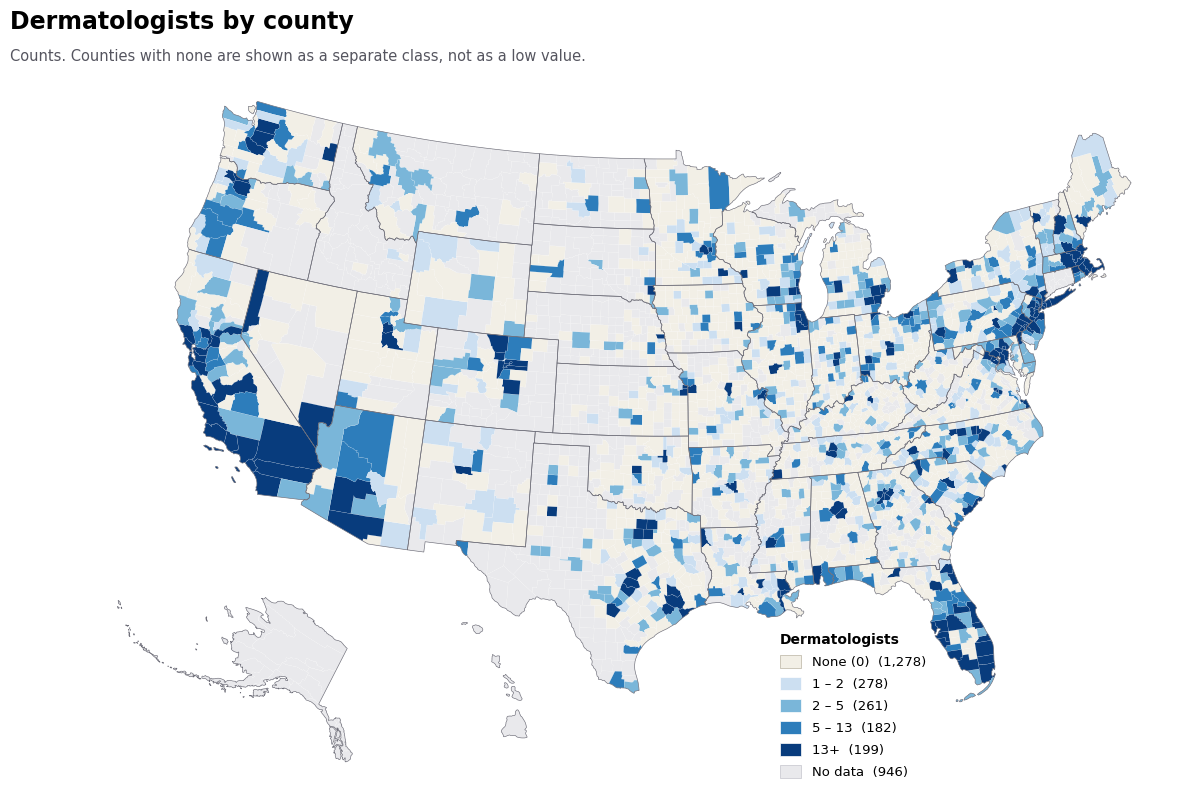

array([  1.,   2.,   5.,  13., 465.])

In [8]:
univariate_map(
    col=CONFIG["derm_count"],
    title="Dermatologists by county",
    subtitle="Counts. Counties with none are shown as a separate class, not as a low value.",
    legend_title="Dermatologists",
    cmap="Blues",
    zero_label="None (0)",
    fname="map_01_dermatologist_count.png",
    fmt=lambda v: f"{v:,.0f}",
)

## Step 9 · Map 2 — Dermatologist density (rate)

  saved -> outputs/map_02_dermatologist_rate.png


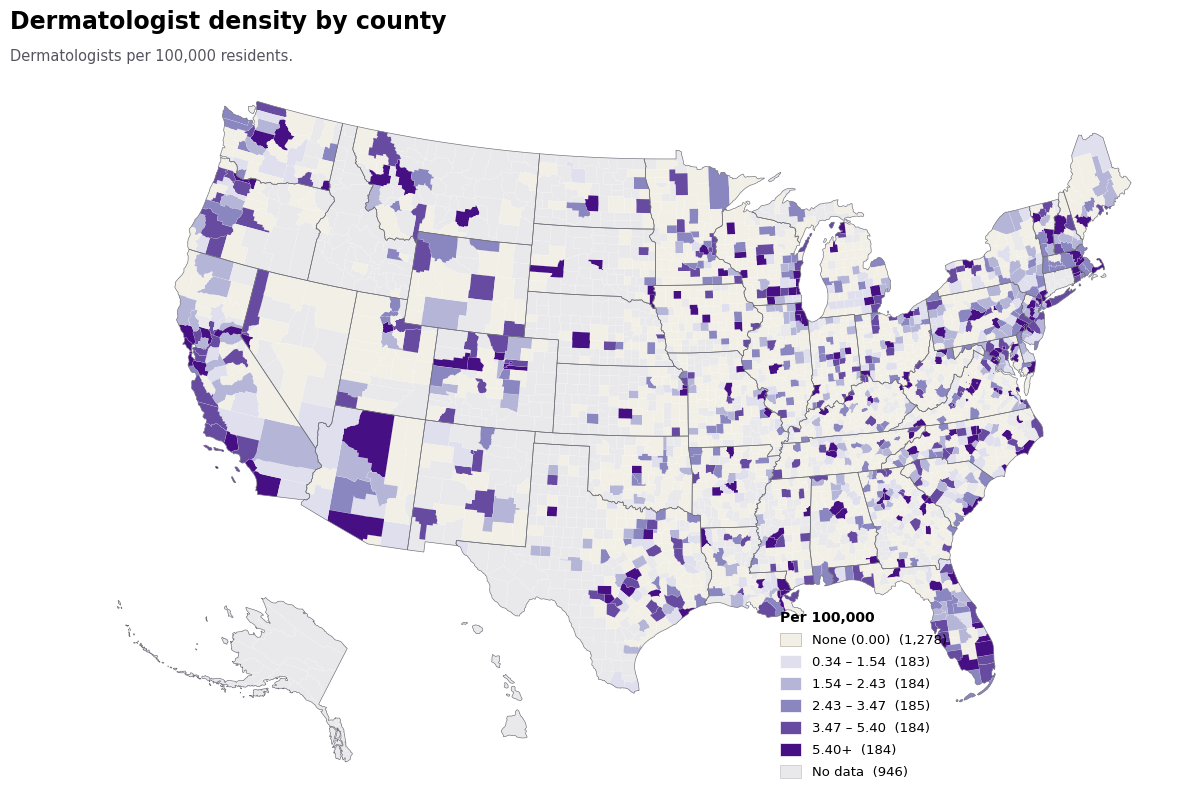

array([  0.34 ,   1.54 ,   2.43 ,   3.474,   5.402, 142.62 ])

In [9]:
univariate_map(
    col=CONFIG["derm_rate"],
    title="Dermatologist density by county",
    subtitle="Dermatologists per 100,000 residents.",
    legend_title="Per 100,000",
    cmap="Purples",
    zero_label="None (0.00)",
    fname="map_02_dermatologist_rate.png",
)

## Step 10 · Map 3 — Any dermatologist (binary)

  saved -> outputs/map_03_any_dermatologist.png


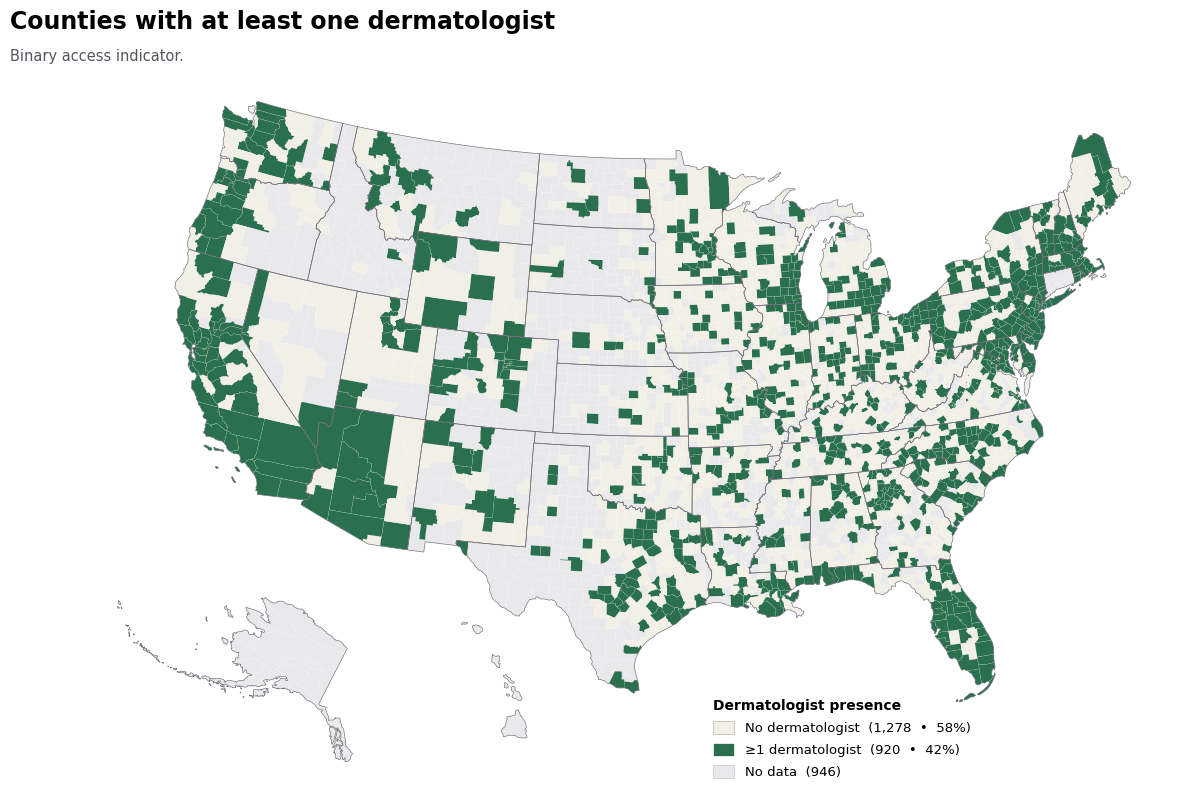

In [10]:
v    = pd.to_numeric(gdf[CONFIG["any_derm"]], errors="coerce")
face = np.where(v.isna(), NODATA_FACE, np.where(v > 0, "#2a6f4e", ZERO_FACE))
n0, n1 = int((v == 0).sum()), int((v > 0).sum())
tot = max(n0 + n1, 1)

fig, ax = _frame("Counties with at least one dermatologist",
                 "Binary access indicator.")
gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
add_state_outlines(gdf, ax)

h = [Patch(facecolor=ZERO_FACE, edgecolor="#b9b3a2", lw=.5,
           label=f"No dermatologist  ({n0:,}  •  {n0/tot*100:.0f}%)"),
     Patch(facecolor="#2a6f4e", edgecolor="white", lw=.5,
           label=f"≥1 dermatologist  ({n1:,}  •  {n1/tot*100:.0f}%)")]
if v.isna().any():
    h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                   label=f"No data  ({int(v.isna().sum()):,})"))
_legend(ax, h, "Dermatologist presence", x=0.575)
_finish(fig, ax, "map_03_any_dermatologist.png")

## Step 11 · Bivariate map helper

A **true bivariate choropleth**: each county is coloured by its position in a 3×3 grid
formed by crossing tertiles of a dermatology measure (x) with tertiles of melanoma
mortality (y). The legend is the colour grid itself.

The policy-relevant cell is the **top-left** — *lowest access, highest mortality* — which
the map annotates with a county count. For the binary `anyderm` variable the grid
collapses to 2×3.

In [11]:
def tertiles(s, n=3):
    v = pd.to_numeric(pd.Series(s).reset_index(drop=True), errors="coerce")
    try:
        c = pd.qcut(v, n, labels=False, duplicates="drop")
        if c.nunique(dropna=True) != n:
            raise ValueError
    except Exception:
        c = pd.qcut(v.rank(method="first"), n, labels=False)   # tie-safe fallback
    lo = [v[c == i].min() for i in range(n)]
    hi = [v[c == i].max() for i in range(n)]
    return c, lo, hi


def bivariate_map(xcol, title, subtitle, xlab, fname, x_binary=False):
    d  = gdf.reset_index(drop=True)
    yc, ylo, yhi = tertiles(d[CONFIG["mort_rate"]])

    if x_binary:
        xv = pd.to_numeric(d[xcol], errors="coerce")
        xc = xv.where(xv.isna(), (xv > 0).astype(float))
        ncol = 2
        grid = [[BIV3[r][0], BIV3[r][2]] for r in range(3)]
    else:
        xc, xlo, xhi = tertiles(d[xcol])
        ncol, grid = 3, BIV3

    face = [NODATA_FACE if (pd.isna(a) or pd.isna(b)) else grid[int(b)][int(a)]
            for a, b in zip(xc, yc)]

    fig, ax = _frame(title, subtitle)
    d.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    add_state_outlines(d, ax)

    # --- 2-D colour-grid legend, drawn in its own inset axes ---
    lx = fig.add_axes([0.600, 0.105, 0.112, 0.175])
    for r in range(3):
        for c in range(ncol):
            lx.add_patch(plt.Rectangle((c, r), 1, 1, facecolor=grid[r][c],
                                       edgecolor="white", linewidth=1.4))
    lx.set_xlim(0, ncol); lx.set_ylim(0, 3); lx.set_aspect("equal")
    lx.set_xticks([]); lx.set_yticks([])
    for sp in lx.spines.values():
        sp.set_visible(False)
    lx.annotate("", xy=(ncol, -0.26), xytext=(0, -0.26), annotation_clip=False,
                arrowprops=dict(arrowstyle="->", lw=1.1, color="#44444c"))
    lx.annotate("", xy=(-0.26, 3), xytext=(-0.26, 0), annotation_clip=False,
                arrowprops=dict(arrowstyle="->", lw=1.1, color="#44444c"))
    lx.text(ncol / 2, -0.58, xlab, ha="center", va="top",
            fontsize=8.8, color="#44444c", clip_on=False)
    lx.text(-0.58, 1.5, "Melanoma mortality →", ha="center", va="center",
            rotation=90, fontsize=8.8, color="#44444c", clip_on=False)

    # Annotations in FIGURE coordinates - axes coords shift under aspect="equal"
    n_pri = int(((xc == 0) & (yc == 2)).sum())
    pri_lab = ("No dermatologist,\nhighest-mortality tertile" if x_binary
               else "Lowest access,\nhighest mortality tertile")
    fig.text(0.734, 0.276, f"Priority cell\n{pri_lab}\n{n_pri:,} counties",
             fontsize=9.4, color="#7a1f36", va="top", ha="left", linespacing=1.6,
             bbox=dict(boxstyle="round,pad=0.45", facecolor="white",
                       edgecolor="#e3d3d8", linewidth=.8, alpha=.93))
    if pd.isna(xc).any() or pd.isna(yc).any():
        fig.legend(handles=[Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE,
                                  lw=.5, label="No data")],
                   loc="lower left", bbox_to_anchor=(0.728, 0.105),
                   bbox_transform=fig.transFigure, frameon=False, fontsize=9.4)

    _finish(fig, ax, fname)

    tab = (pd.crosstab(yc, xc, dropna=True)
             .rename_axis(index="mortality tertile", columns="access class"))
    tab.index = ["low", "mid", "high"][:len(tab)]
    tab.columns = (["no derm", "has derm"] if x_binary else ["low", "mid", "high"])[:tab.shape[1]]
    print("\nCounty counts in each bivariate cell:")
    display(tab)
    return n_pri

print("Bivariate helper ready.")

Bivariate helper ready.


## Step 12 · Bivariate map 1 — Dermatologist count × melanoma mortality

  saved -> outputs/map_04_bivariate_count_x_mortality.png


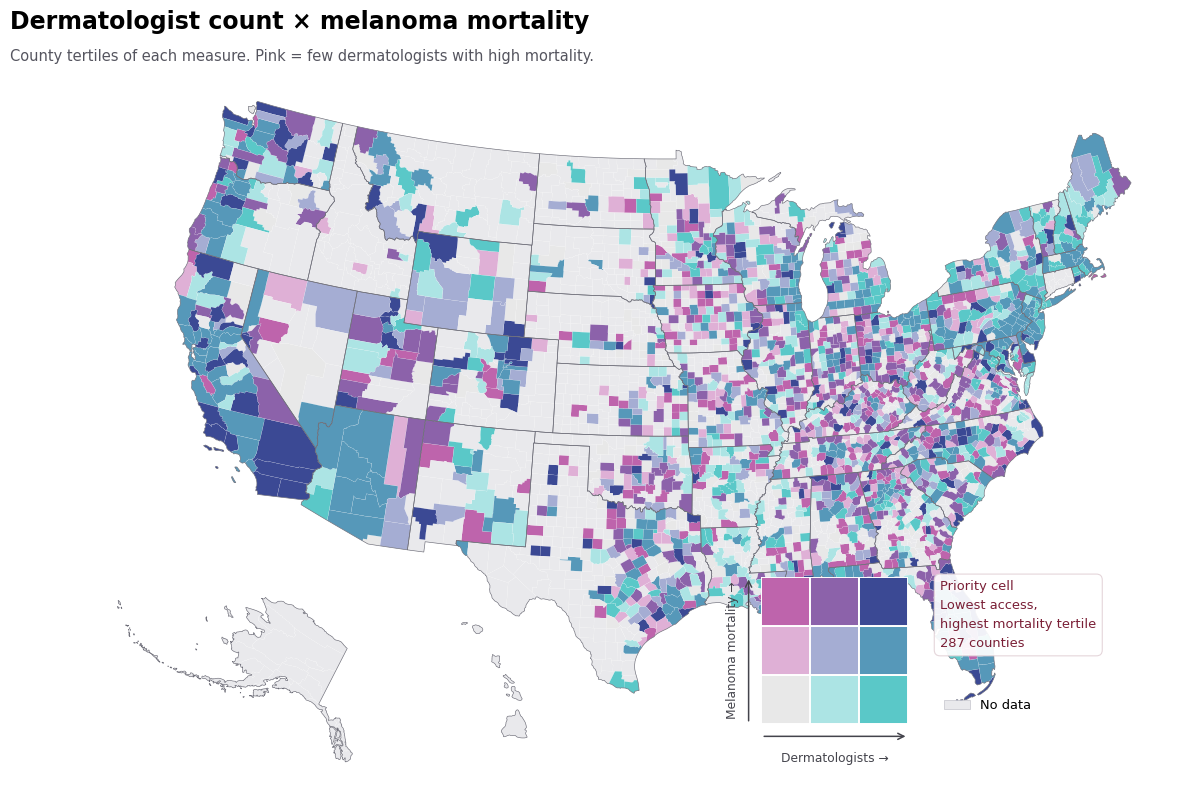


County counts in each bivariate cell:


,low,mid,high
low,259,269,209
mid,187,201,351
high,287,262,173


In [12]:
n1 = bivariate_map(
    xcol=CONFIG["derm_count"],
    title="Dermatologist count × melanoma mortality",
    subtitle="County tertiles of each measure. Pink = few dermatologists with high mortality.",
    xlab="Dermatologists →",
    fname="map_04_bivariate_count_x_mortality.png",
)

## Step 13 · Bivariate map 2 — Dermatologist density × melanoma mortality

  saved -> outputs/map_05_bivariate_rate_x_mortality.png


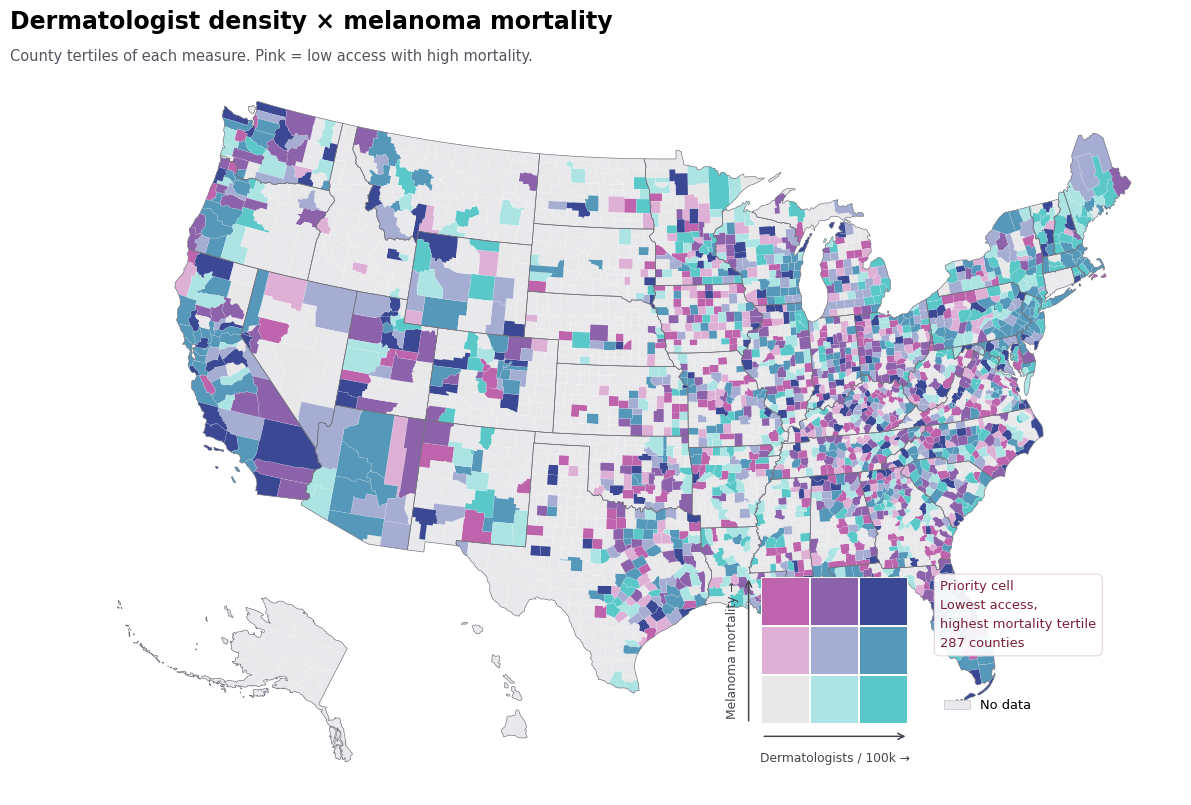


County counts in each bivariate cell:


,low,mid,high
low,259,258,220
mid,187,231,321
high,287,243,192


In [13]:
n2 = bivariate_map(
    xcol=CONFIG["derm_rate"],
    title="Dermatologist density × melanoma mortality",
    subtitle="County tertiles of each measure. Pink = low access with high mortality.",
    xlab="Dermatologists / 100k →",
    fname="map_05_bivariate_rate_x_mortality.png",
)

## Step 14 · Bivariate map 3 — Any dermatologist × melanoma mortality

  saved -> outputs/map_06_bivariate_anyderm_x_mortality.png


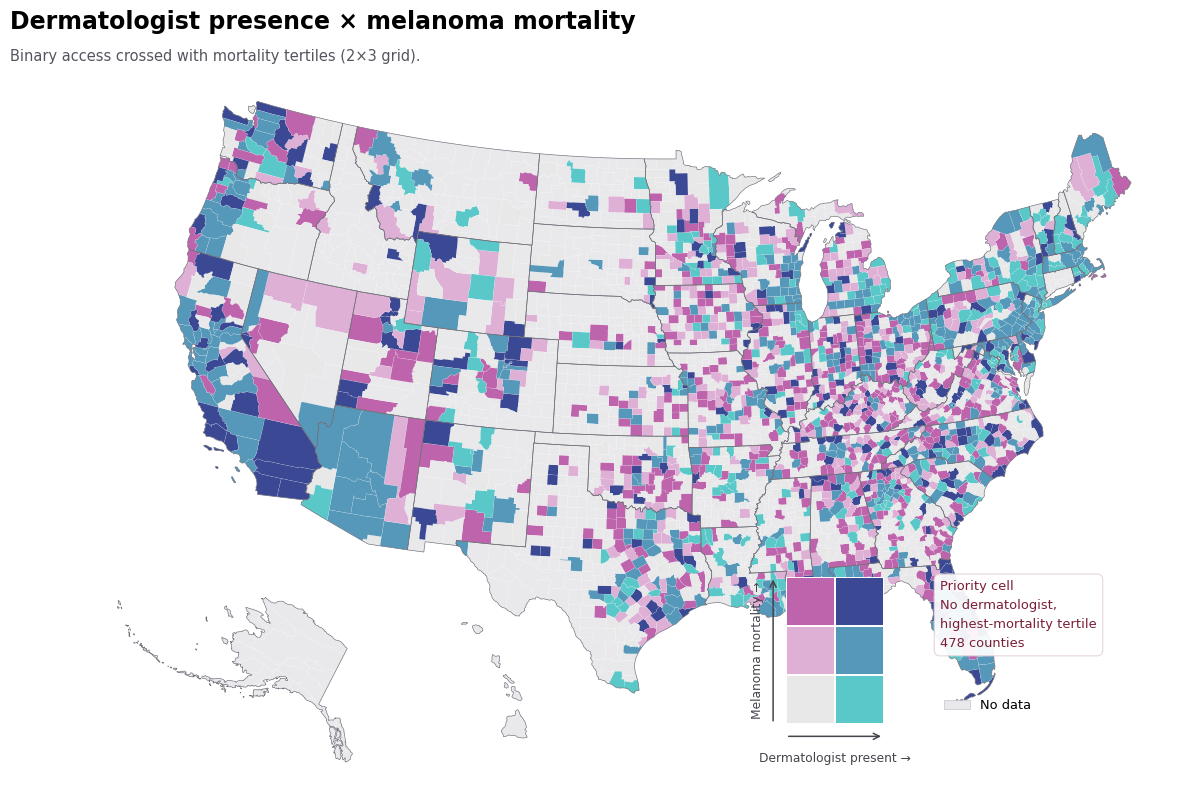


County counts in each bivariate cell:


,no derm,has derm
low,469,268
mid,331,408
high,478,244


In [14]:
n3 = bivariate_map(
    xcol=CONFIG["any_derm"],
    title="Dermatologist presence × melanoma mortality",
    subtitle="Binary access crossed with mortality tertiles (2×3 grid).",
    xlab="Dermatologist present →",
    fname="map_06_bivariate_anyderm_x_mortality.png",
    x_binary=True,
)

## Step 15 · Spatial weights

**Queen contiguity** built from the actual county polygons — two counties are neighbours
if they share any boundary point. This is the correct adjacency structure for areal data;
k-nearest-neighbours on centroids would link counties across state lines and water.

Weights are built on the **unrepositioned** geometry so the Alaska/Hawaii insets cannot
create phantom adjacencies. Island counties (no shared boundary) are attached to their
single nearest neighbour so they are not silently dropped from the analysis.

In [15]:
from libpysal.weights import Queen, KNN, attach_islands
from libpysal.weights import W as PysalW

# analysis frame: counties that actually carry your data, original (un-inset) geometry
analysis = (g.merge(df, on="FIPS", how="inner")
              .to_crs(CRS_ALBERS)
              .reset_index(drop=True))
analysis = analysis[analysis[CONFIG["mort_rate"]].notna()].reset_index(drop=True)
print(f"Analysis set: {len(analysis):,} counties with complete data\n")

w = Queen.from_dataframe(analysis, use_index=False, silence_warnings=True)
if len(w.islands):
    print(f"  {len(w.islands)} island counties -> attaching nearest neighbour")
    w = attach_islands(w, KNN.from_dataframe(analysis, k=1, silence_warnings=True),
                       silence_warnings=True)
w.transform = "r"

card = np.array(list(w.cardinalities.values()))
print(f"  Queen contiguity: n={w.n:,}, mean neighbours={card.mean():.2f}, "
      f"range {card.min()}–{card.max()}")


def pop_scaled_weights(w_base, pop):
    # Row-standardised W: each neighbour's weight is proportional to its population
    pop = np.asarray(pop, float)
    ids = list(w_base.id_order)
    pos = {k: i for i, k in enumerate(ids)}
    nb, wt = {}, {}
    for k in ids:
        nk = list(w_base.neighbors[k])
        nb[k] = nk
        if not nk:
            wt[k] = []
            continue
        raw = np.array([pop[pos[j]] for j in nk], float)
        wt[k] = list(raw / raw.sum()) if raw.sum() > 0 else [1 / len(nk)] * len(nk)
    return PysalW(nb, wt, id_order=ids, silence_warnings=True)

w_pop = pop_scaled_weights(w, analysis[CONFIG["weight"]].values)
print(f"  Population-scaled W built (neighbour influence ∝ {CONFIG['weight']})")

Analysis set: 2,198 counties with complete data

  20 island counties -> attaching nearest neighbour
  Queen contiguity: n=2,198, mean neighbours=4.88, range 1–10
  Population-scaled W built (neighbour influence ∝ pop)


## Step 16 · Global Moran's I — four specifications

Reporting several specifications side by side is the honest move: it shows whether a
clustering result is a real spatial signal or an artefact of unstable small-county rates.

| Spec | What it does |
|---|---|
| **A. Raw rate** | Naive baseline. Small-denominator counties add noise. |
| **B. EB rate (pop-weighted)** | Assunção–Reis empirical-Bayes smoothing on events/population. **Primary result.** |
| **C. Pop-scaled W** | Neighbour influence proportional to population. |
| **D. Derm access, EB** | Same treatment applied to the access measure. |

In [16]:
from esda.moran import Moran, Moran_Rate

P = CONFIG["permutations"]
np.random.seed(CONFIG["random_seed"])

mort_rate = analysis[CONFIG["mort_rate"]].values
mort_e    = analysis[CONFIG["mort_event"]].values
mort_b    = analysis[CONFIG["mort_denom"]].values
derm_e    = analysis[CONFIG["derm_count"]].values
derm_b    = analysis[CONFIG["derm_denom"]].values

specs = {
    "A. Melanoma mortality, raw rate":        Moran(mort_rate, w, permutations=P),
    "B. Melanoma mortality, EB (pop-wtd)":    Moran_Rate(mort_e, mort_b, w, permutations=P),
    "C. Melanoma mortality, pop-scaled W":    Moran(mort_rate, w_pop, permutations=P),
    "D. Dermatologist access, EB (pop-wtd)":  Moran_Rate(derm_e, derm_b, w, permutations=P),
}

rows = []
for name, m in specs.items():
    if   m.p_sim < 0.001: stars = "***"
    elif m.p_sim < 0.01:  stars = "**"
    elif m.p_sim < 0.05:  stars = "*"
    else:                 stars = ""
    rows.append({
        "Specification": name,
        "Moran's I": round(float(m.I), 4),
        "E[I]": round(float(m.EI), 5),
        "z": round(float(m.z_sim), 2),
        "p (perm)": f"{m.p_sim:.4f}{stars}",
        "Pattern": ("clustered" if m.p_sim < 0.05 and m.I > m.EI
                    else "dispersed" if m.p_sim < 0.05 else "random"),
    })

moran_tbl = pd.DataFrame(rows)
display(moran_tbl)
print(f"{P} conditional permutations.  * p<.05  ** p<.01  *** p<.001")
print("\nSpec B is the headline number: it is the one that accounts for unstable")
print("rates in small-population counties.")
moran_tbl.to_csv(os.path.join(CONFIG["out_dir"], "global_morans_i.csv"), index=False)

,Specification,Moran's I,E[I],z,p (perm),Pattern
0,"A. Melanoma mortality, raw rate",0.0437,-0.00046,3.04,0.0030**,clustered
1,"B. Melanoma mortality, EB (pop-wtd)",0.1739,-0.00046,11.62,0.0010**,clustered
2,"C. Melanoma mortality, pop-scaled W",0.0503,-0.00046,3.28,0.0020**,clustered
3,"D. Dermatologist access, EB (pop-wtd)",0.1545,-0.00046,9.85,0.0020**,clustered


999 conditional permutations.  * p<.05  ** p<.01  *** p<.001

Spec B is the headline number: it is the one that accounts for unstable
rates in small-population counties.


## Step 17 · LISA — local clusters

Local Moran's I on **EB-smoothed rates**, so the population weight carries through to the
local statistics. Each county is assigned a quadrant, shown only where *p* < 0.05:

- **High–High** — high value surrounded by high values (a hotspot)
- **Low–Low** — a coldspot
- **Low–High / High–Low** — spatial outliers

> Local Moran's I runs thousands of tests at once, so treat *p* < 0.05 as a screening
> threshold for generating hypotheses, not as confirmatory inference. An FDR-adjusted
> version is computed alongside it below.

In [17]:
from esda.moran import Moran_Local_Rate

def fdr_bh(p, q=0.05):
    # Benjamini-Hochberg: returns a boolean mask of discoveries
    p = np.asarray(p, float)
    n = p.size
    order = np.argsort(p)
    thresh = q * (np.arange(1, n + 1) / n)
    passed = p[order] <= thresh
    keep = np.zeros(n, bool)
    if passed.any():
        keep[order[:np.max(np.where(passed)[0]) + 1]] = True
    return keep

def lisa_quadrants(local, alpha=0.05):
    sig = local.p_sim < alpha
    return np.where(sig, local.q, 0), fdr_bh(local.p_sim, alpha)

np.random.seed(CONFIG["random_seed"])
l_mort = Moran_Local_Rate(mort_e, mort_b, w, permutations=P)
l_derm = Moran_Local_Rate(derm_e, derm_b, w, permutations=P)

analysis["lisa_mortality"], fdr_m = lisa_quadrants(l_mort)
analysis["lisa_derm"],      fdr_d = lisa_quadrants(l_derm)
analysis["lisa_mortality_fdr"] = np.where(fdr_m, l_mort.q, 0)
analysis["lisa_derm_fdr"]      = np.where(fdr_d, l_derm.q, 0)

summary = pd.DataFrame({
    "Melanoma mortality": pd.Series(analysis["lisa_mortality"]).map(LISA_LABELS).value_counts(),
    "Mortality (FDR)":    pd.Series(analysis["lisa_mortality_fdr"]).map(LISA_LABELS).value_counts(),
    "Dermatology access": pd.Series(analysis["lisa_derm"]).map(LISA_LABELS).value_counts(),
    "Access (FDR)":       pd.Series(analysis["lisa_derm_fdr"]).map(LISA_LABELS).value_counts(),
}).fillna(0).astype(int)
order = [LISA_LABELS[k] for k in (1, 3, 2, 4, 0)]
display(summary.reindex([o for o in order if o in summary.index]))

,Melanoma mortality,Mortality (FDR),Dermatology access,Access (FDR)
High–High,125,0,87,0
Low–Low,113,0,124,0
Low–High,53,0,46,0
High–Low,46,0,40,0
Not significant,1861,2198,1901,2198


## Step 18 · LISA cluster maps

  saved -> outputs/map_07_lisa_mortality.png


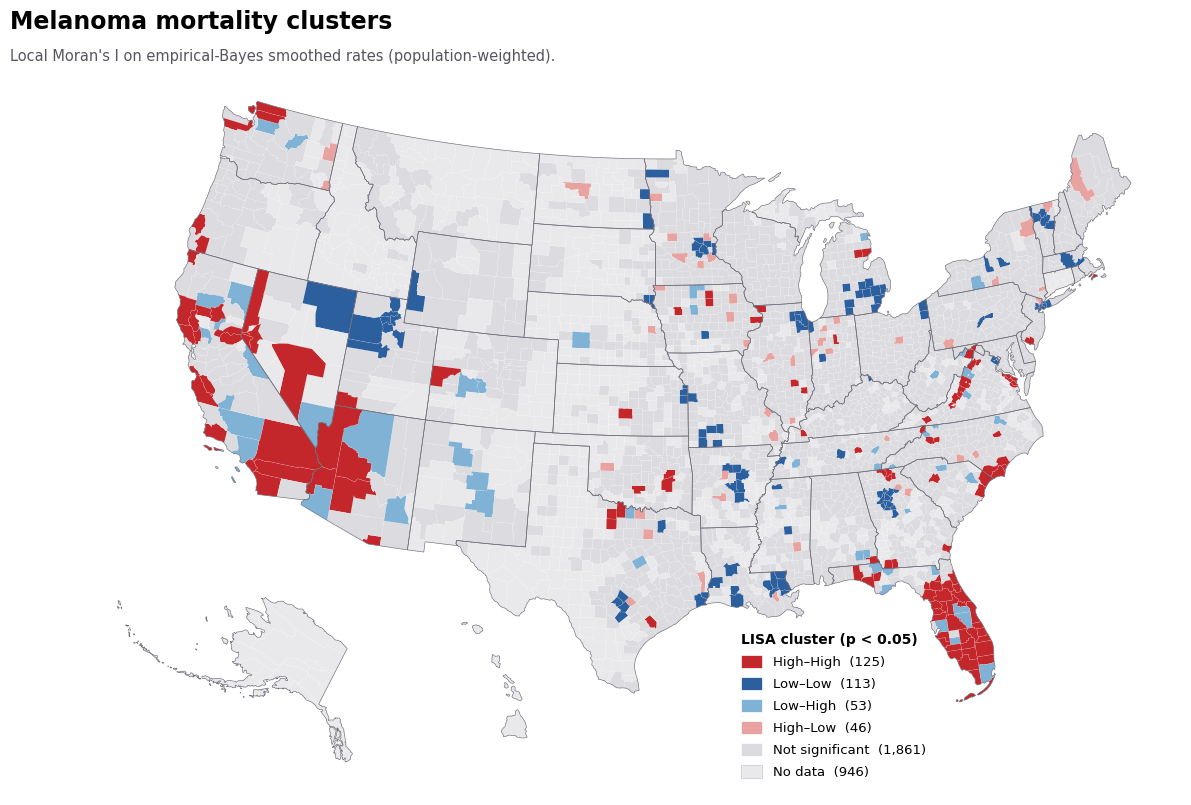

  saved -> outputs/map_08_lisa_dermatology.png


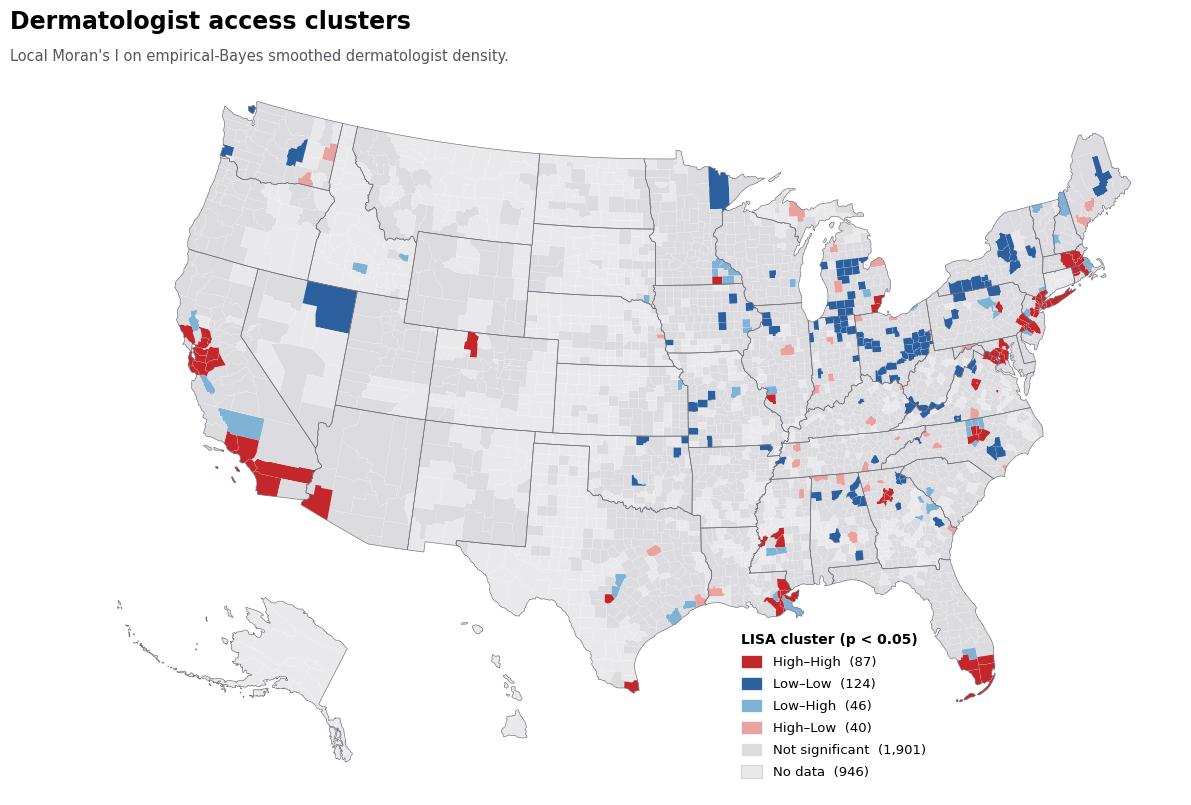

In [18]:
plot_gdf = gdf.merge(
    analysis[["FIPS", "lisa_mortality", "lisa_derm",
              "lisa_mortality_fdr", "lisa_derm_fdr"]],
    on="FIPS", how="left")

def lisa_map(qcol, title, subtitle, fname):
    q    = plot_gdf[qcol]
    face = [LISA_COLORS[int(x)] if pd.notna(x) else NODATA_FACE for x in q]
    cnt  = q.value_counts()

    fig, ax = _frame(title, subtitle)
    plot_gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
    add_state_outlines(plot_gdf, ax)

    h = [Patch(facecolor=LISA_COLORS[k], edgecolor="white", lw=.5,
               label=f"{LISA_LABELS[k]}  ({int(cnt.get(k, 0)):,})") for k in (1, 3, 2, 4, 0)]
    if q.isna().any():
        h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5,
                       label=f"No data  ({int(q.isna().sum()):,})"))
    _legend(ax, h, "LISA cluster (p < 0.05)", x=0.60)
    _finish(fig, ax, fname)

lisa_map("lisa_mortality",
         "Melanoma mortality clusters",
         "Local Moran's I on empirical-Bayes smoothed rates (population-weighted).",
         "map_07_lisa_mortality.png")

lisa_map("lisa_derm",
         "Dermatologist access clusters",
         "Local Moran's I on empirical-Bayes smoothed dermatologist density.",
         "map_08_lisa_dermatology.png")

## Step 19 · Bivariate LISA — the key analytic map

This is the one that answers the research question. **Bivariate Local Moran's I** measures
whether a county's dermatology access is associated with melanoma mortality *in its
neighbours*. Quadrants read differently here:

- **Low–High** — low local access surrounded by high mortality → **the access-gap clusters**
- **High–Low** — high access surrounded by low mortality
- **High–High / Low–Low** — access and neighbouring mortality move together

A negative global bivariate I is what the access-protects-against-mortality hypothesis
predicts. Note this is an ecological association, not a causal estimate.

GLOBAL BIVARIATE MORAN'S I  (dermatologist density vs neighbours' mortality)
  I = -0.0397   p = 0.0010
  -> negative: higher access sits beside lower mortality
  saved -> outputs/map_09_bivariate_lisa.png


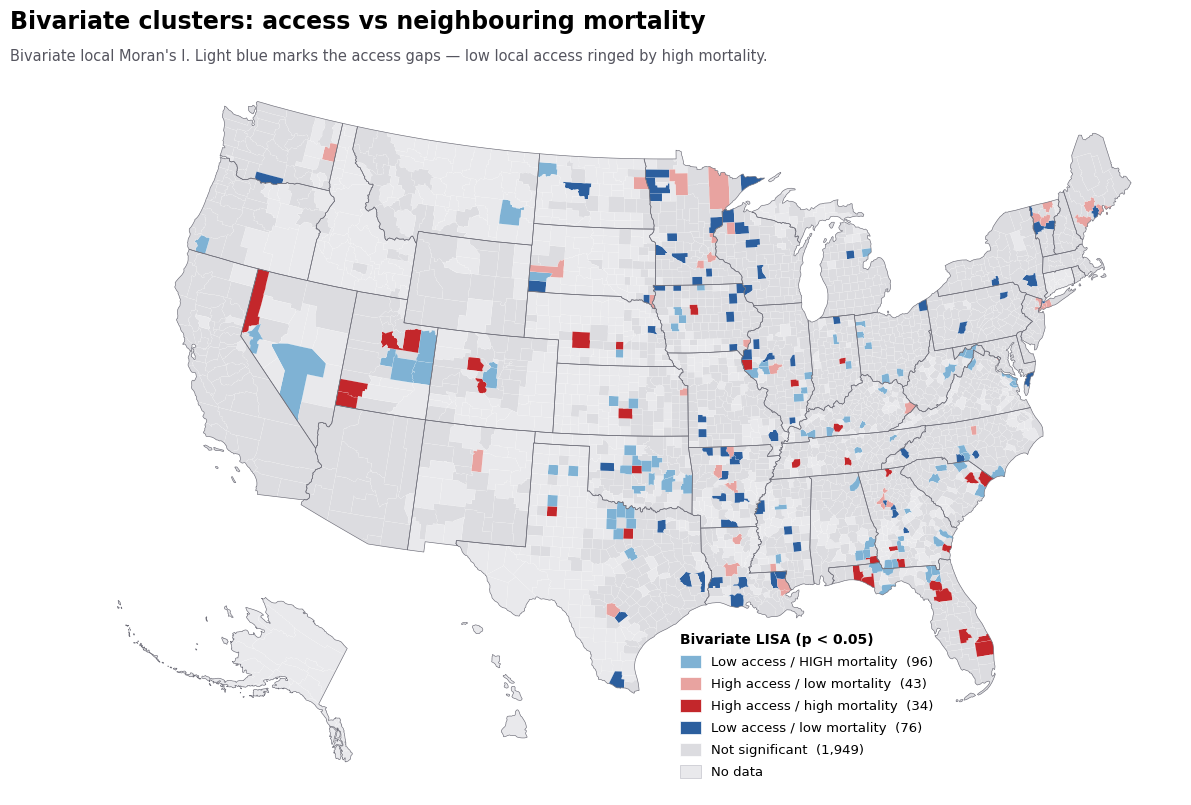


ACCESS-GAP CLUSTERS (low access, high neighbouring mortality): 96 counties


In [19]:
from esda.moran import Moran_BV, Moran_Local_BV

np.random.seed(CONFIG["random_seed"])
x_access = analysis[CONFIG["derm_rate"]].values
y_mort   = analysis[CONFIG["mort_rate"]].values

m_bv = Moran_BV(x_access, y_mort, w, permutations=P)
print("GLOBAL BIVARIATE MORAN'S I  (dermatologist density vs neighbours' mortality)")
print(f"  I = {m_bv.I:+.4f}   p = {m_bv.p_sim:.4f}")
print("  ->", "negative: higher access sits beside lower mortality" if m_bv.I < 0
      else "positive: higher access sits beside higher mortality")

l_bv = Moran_Local_BV(x_access, y_mort, w, permutations=P)
analysis["lisa_bivariate"] = np.where(l_bv.p_sim < 0.05, l_bv.q, 0)

plot_gdf = plot_gdf.merge(analysis[["FIPS", "lisa_bivariate"]], on="FIPS", how="left")

q    = plot_gdf["lisa_bivariate"]
face = [LISA_COLORS[int(x)] if pd.notna(x) else NODATA_FACE for x in q]
cnt  = q.value_counts()

BV_LABELS = {0: "Not significant",
             1: "High access / high mortality",
             2: "Low access / HIGH mortality",
             3: "Low access / low mortality",
             4: "High access / low mortality"}

fig, ax = _frame("Bivariate clusters: access vs neighbouring mortality",
                 "Bivariate local Moran's I. Light blue marks the access gaps — "
                 "low local access ringed by high mortality.")
plot_gdf.plot(ax=ax, color=face, edgecolor=EDGE_COLOR, linewidth=EDGE_WIDTH)
add_state_outlines(plot_gdf, ax)
h = [Patch(facecolor=LISA_COLORS[k], edgecolor="white", lw=.5,
           label=f"{BV_LABELS[k]}  ({int(cnt.get(k, 0)):,})") for k in (2, 4, 1, 3, 0)]
if q.isna().any():
    h.append(Patch(facecolor=NODATA_FACE, edgecolor=NODATA_EDGE, lw=.5, label="No data"))
_legend(ax, h, "Bivariate LISA (p < 0.05)", x=0.545)
_finish(fig, ax, "map_09_bivariate_lisa.png")

print(f"\nACCESS-GAP CLUSTERS (low access, high neighbouring mortality): "
      f"{int((analysis['lisa_bivariate'] == 2).sum()):,} counties")

## Step 20 · Population-weighted association and the priority county list

Unweighted county correlations let a 400-person county count as much as Cook County.
Both are reported so the gap between them is visible.

In [20]:
from scipy.stats import pearsonr, spearmanr

def weighted_pearson(x, y, wt):
    x, y, wt = (np.asarray(a, float) for a in (x, y, wt))
    m = np.isfinite(x) & np.isfinite(y) & np.isfinite(wt) & (wt > 0)
    x, y, wt = x[m], y[m], wt[m]
    mx, my = np.average(x, weights=wt), np.average(y, weights=wt)
    cov = np.average((x - mx) * (y - my), weights=wt)
    return cov / np.sqrt(np.average((x - mx) ** 2, weights=wt) *
                         np.average((y - my) ** 2, weights=wt))

wt = analysis[CONFIG["weight"]].values
rows = []
for label, xv in [("Dermatologist count", analysis[CONFIG["derm_count"]].values),
                  ("Dermatologist density", x_access),
                  ("Any dermatologist (0/1)", analysis[CONFIG["any_derm"]].values)]:
    m = np.isfinite(xv) & np.isfinite(y_mort)
    r_u, p_u = pearsonr(xv[m], y_mort[m])
    rho, p_s = spearmanr(xv[m], y_mort[m])
    rows.append({
        "Measure": label,
        "Pearson r (unweighted)": round(r_u, 4),
        "p": f"{p_u:.2e}",
        "Spearman rho": round(rho, 4),
        f"Pearson r (weighted by {CONFIG['weight']})": round(weighted_pearson(xv, y_mort, wt), 4),
    })
corr_tbl = pd.DataFrame(rows)
display(corr_tbl)
corr_tbl.to_csv(os.path.join(CONFIG["out_dir"], "correlations.csv"), index=False)

# ---- priority counties -------------------------------------------------
acc_lo  = np.nanpercentile(x_access, 25)
mort_hi = np.nanpercentile(y_mort, 75)

priority = analysis[(analysis[CONFIG["derm_rate"]] <= acc_lo) &
                    (analysis[CONFIG["mort_rate"]] >= mort_hi)].copy()
priority["access_gap_cluster"] = priority["lisa_bivariate"] == 2
priority = priority.sort_values(
    ["access_gap_cluster", CONFIG["mort_denom"], CONFIG["mort_rate"]],
    ascending=[False, False, False])

cols = ["FIPS", "state", CONFIG["derm_count"], CONFIG["derm_rate"],
        CONFIG["any_derm"], CONFIG["mort_event"], CONFIG["mort_rate"],
        CONFIG["mort_denom"], "access_gap_cluster"]
cols = [c for c in cols if c in priority.columns]

print(f"\nPRIORITY COUNTIES  — bottom-quartile access (≤{acc_lo:.2f} per 100k) "
      f"AND top-quartile mortality (≥{mort_hi:.2f} per 100k)")
print(f"  {len(priority):,} counties, "
      f"{int(priority[CONFIG['mort_denom']].sum()):,} people, "
      f"{int(priority[CONFIG['mort_event']].sum()):,} melanoma deaths")
print(f"  of which {int(priority['access_gap_cluster'].sum()):,} also sit in a "
      f"significant bivariate access-gap cluster\n")
display(priority[cols].head(25))
priority[cols].to_csv(os.path.join(CONFIG["out_dir"], "priority_counties.csv"), index=False)

,Measure,Pearson r (unweighted),p,Spearman rho,Pearson r (weighted by pop)
0,Dermatologist count,-0.0659,1.98e-03,-0.0517,-0.1120
1,Dermatologist density,-0.0689,1.23e-03,-0.0440,-0.1593
2,Any dermatologist (0/1),-0.1030,1.31e-06,-0.0335,-0.1243



PRIORITY COUNTIES  — bottom-quartile access (≤0.00 per 100k) AND top-quartile mortality (≥3.40 per 100k)
  414 counties, 48,849,976 people, 3,071 melanoma deaths
  of which 30 also sit in a significant bivariate access-gap cluster



,FIPS,state,dermatologists,dermatology_rate,anyderm,melanoma_deaths,melanoma_mortality_rate,pop,access_gap_cluster
1624,40017,oklahoma,0,0.0,0,26,3.4,626319,True
1566,32019,nevada,0,0.0,0,16,4.8,227417,True
2180,51171,virginia,0,0.0,0,13,3.9,192910,True
567,39039,ohio,0,0.0,0,9,3.4,164400,True
2136,40121,oklahoma,0,0.0,0,15,6.8,156786,True
1978,49047,utah,0,0.0,0,5,3.5,153181,True
1919,39001,ohio,0,0.0,0,7,3.9,133359,True
1546,13179,georgia,0,0.0,0,5,4.0,129509,True
260,49039,utah,0,0.0,0,6,4.2,126881,True
757,54027,west virginia,0,0.0,0,10,5.7,112605,True


## Step 21 · Export results and download

In [21]:
out = analysis.drop(columns="geometry").copy()
for c, lab in [("lisa_mortality", "lisa_mortality_label"),
               ("lisa_derm", "lisa_derm_label")]:
    out[lab] = out[c].map(LISA_LABELS)
out["lisa_bivariate_label"] = out["lisa_bivariate"].map(BV_LABELS)

res_path = os.path.join(CONFIG["out_dir"], "county_spatial_results.csv")
out.to_csv(res_path, index=False)
print(f"saved -> {res_path}  ({len(out):,} counties x {out.shape[1]} cols)")

readme = f"""SPATIAL ANALYSIS RESULTS
{'=' * 60}
Counties analysed : {len(analysis):,}
Geometry source   : {geo_source}
Projection        : Albers Equal Area (EPSG:5070)
Spatial weights   : Queen contiguity, row-standardised, islands attached via KNN(1)
Permutations      : {P}
Population weight : {CONFIG['weight']}

GLOBAL MORAN'S I
{moran_tbl.to_string(index=False)}

GLOBAL BIVARIATE MORAN'S I (access vs neighbouring mortality)
  I = {m_bv.I:+.4f}   p = {m_bv.p_sim:.4f}

LISA CLUSTER COUNTS
{summary.to_string()}

ACCESS-GAP CLUSTERS (low access / high neighbouring mortality)
  {int((analysis['lisa_bivariate'] == 2).sum()):,} counties

PRIORITY COUNTIES (bottom-quartile access + top-quartile mortality)
  {len(priority):,} counties
  {int(priority[CONFIG['mort_denom']].sum()):,} people
  {int(priority[CONFIG['mort_event']].sum()):,} melanoma deaths

CORRELATIONS
{corr_tbl.to_string(index=False)}

NOTE: county-level (ecological) associations. They do not license
individual-level or causal conclusions.
"""
with open(os.path.join(CONFIG["out_dir"], "README.txt"), "w") as fh:
    fh.write(readme)
print(readme)

saved -> outputs/county_spatial_results.csv  (2,198 counties x 28 cols)
SPATIAL ANALYSIS RESULTS
Counties analysed : 2,198
Geometry source   : Census TIGER cb_2023_us_county_20m
Projection        : Albers Equal Area (EPSG:5070)
Spatial weights   : Queen contiguity, row-standardised, islands attached via KNN(1)
Permutations      : 999
Population weight : pop

GLOBAL MORAN'S I
                        Specification  Moran's I     E[I]     z p (perm)   Pattern
      A. Melanoma mortality, raw rate     0.0437 -0.00046  3.04 0.0030** clustered
  B. Melanoma mortality, EB (pop-wtd)     0.1739 -0.00046 11.62 0.0010** clustered
  C. Melanoma mortality, pop-scaled W     0.0503 -0.00046  3.28 0.0020** clustered
D. Dermatologist access, EB (pop-wtd)     0.1545 -0.00046  9.85 0.0020** clustered

GLOBAL BIVARIATE MORAN'S I (access vs neighbouring mortality)
  I = -0.0397   p = 0.0010

LISA CLUSTER COUNTS
                 Melanoma mortality  Mortality (FDR)  Dermatology access  Access (FDR)
High–High

In [22]:
# Zip everything and download (Colab only)
import glob, shutil
zip_base = "spatial_analysis_outputs"
shutil.make_archive(zip_base, "zip", CONFIG["out_dir"])
print("Files produced:")
for f in sorted(glob.glob(os.path.join(CONFIG["out_dir"], "*"))):
    print(f"  {os.path.basename(f):45s} {os.path.getsize(f)/1024:8.1f} KB")

try:
    from google.colab import files
    files.download(zip_base + ".zip")
    print(f"\nDownloading {zip_base}.zip")
except ImportError:
    print(f"\nNot in Colab - archive written to {os.path.abspath(zip_base + '.zip')}")

Files produced:
  README.txt                                         2.1 KB
  correlations.csv                                   0.2 KB
  county_spatial_results.csv                       411.0 KB
  global_morans_i.csv                                0.4 KB
  map_01_dermatologist_count.png                   820.5 KB
  map_02_dermatologist_rate.png                    823.2 KB
  map_03_any_dermatologist.png                     843.7 KB
  map_04_bivariate_count_x_mortality.png           866.1 KB
  map_05_bivariate_rate_x_mortality.png            867.0 KB
  map_06_bivariate_anyderm_x_mortality.png         865.8 KB
  map_07_lisa_mortality.png                        772.8 KB
  map_08_lisa_dermatology.png                      759.5 KB
  map_09_bivariate_lisa.png                        784.0 KB
  priority_counties.csv                             18.4 KB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Reading the results

**Global Moran's I.** Positive and significant means melanoma mortality clusters
geographically. Compare spec A with spec B: if raw-rate I is much larger than the
EB-smoothed I, the naive number was inflated by noisy small-county rates, and B is the
one to report.

**LISA maps.** High–High blocks on the mortality map are sustained regional burden, not
single-county noise. Low–Low blocks on the access map are the dermatology deserts. Where
those two overlap geographically is the finding.

**The bivariate LISA map is the headline.** Low–High counties have poor local access
*and* sit inside a high-mortality neighbourhood. That is a different and stronger claim
than either univariate map supports, because it is a statement about a county in its
regional context.

### Interpretation cautions

1. **Ecological inference.** Counties are not people. County-level association does not
   establish that individuals with less access die more often.
2. **Direction is genuinely ambiguous.** A positive access–mortality association is
   common in this literature and usually reflects referral patterns and detection
   intensity — dermatologists concentrate where disease is found — rather than harm from
   care. Do not read the sign as a causal effect.
3. **Mortality lags access by years.** 2019 workforce counts against 2019–2023 deaths
   cannot capture the exposure window that actually produced those deaths.
4. **MAUP.** County boundaries are administrative. Commuting zones or HSAs would give
   different numbers, and testing an alternative geography is a worthwhile robustness check.
5. **Suppressed counts.** If small counties had deaths suppressed before you received
   the file, they are missing non-randomly and the EB smoothing cannot repair that.

### Sensible next steps

- Spatial regression (SAR / SEM, via `spreg`) with covariates: UV exposure, rurality
  (RUCC), median income, uninsured rate, % over 65, and a Southern-latitude indicator.
- Rate-ratio models — negative binomial on death counts with `log(pop)` offset — which
  suit count outcomes better than OLS on rates.
- Two-step floating catchment area (2SFCA) accessibility rather than a within-county
  count, since patients cross county lines for care.
- Sensitivity: re-run against Rook contiguity and KNN(k=6) to confirm the clusters do
  not depend on one adjacency definition.